<a href="https://colab.research.google.com/github/Ayush-jk/Ayush-jk/blob/main/Spectral_classification_of_Chandrayaan_2_IIRS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing the spectral library for reading the **.qub** and **.hdr** files

In [5]:
! pip install spectral

Mount the Gdrive

Specifying the files path to variables

In [9]:
data_file = "/content/hyperspectral_image.qub"
header_file = "/content/image_metadata.hdr"
geometry_file = "/content/geolocation_data.csv"


Reading the data

In [10]:
import spectral
import os

In [11]:
data = spectral.io.envi.open(header_file, image=data_file)

In [12]:
hyperspectral_data = data.load()

In [13]:
print(f"Shape of the data: {hyperspectral_data.shape}")

Shape of the data: (1521, 250, 256)


The shape of the data is (9340 , 250 , 256) .
In the 2D space of 9340 x 250 (lines * samples) each pixel or point has 256 different reflectance values at 256 different wavelengths.

Importing the necessary libraries

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten , MaxPooling2D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Saving the plots using custom `save_fig()` function

In [15]:
IMAGES_PATH = Path() / "images" / "hyperspectral"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Plot of reflectance variation
The `plot_reflectance_variation(x, y)` below plots the reflectance values with respect to the wavelength at the coordinates specified by the user.
*Coordinates must be in the range of (250 , 9340)*

In [16]:
def plot_reflectance_variation(x , y):
  if x >= 0 and x < hyperspectral_data.shape[1] and y >= 0 and y < hyperspectral_data.shape[0]:
    reflectance_values = hyperspectral_data[y, x, :]
    plt.figure(figsize = (10 , 6))
    plt.plot(range(hyperspectral_data.shape[2]), reflectance_values.squeeze())
    plt.xlabel('Wavelength')
    plt.ylabel('Reflectance')
    plt.title(f'Reflectance Variation at ({x}, {y})')
    save_fig("reflectance variation vs wavelength")
    plt.show()
  else:
    print("Invalid coordinates")

Enter the x coordinate: 100
Enter the y coordinate: 200


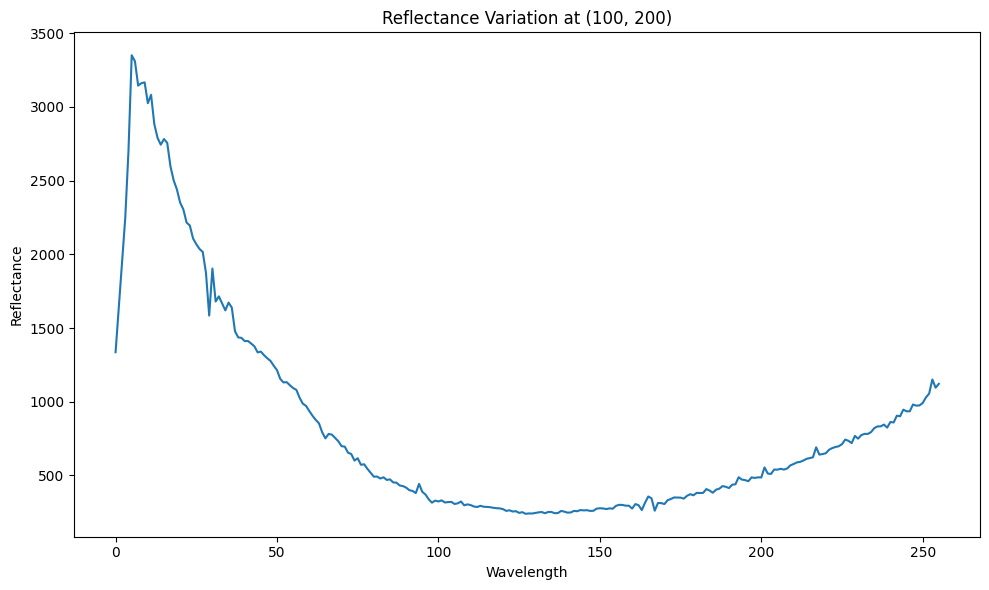

In [17]:
x = int(input("Enter the x coordinate: "))
y = int(input("Enter the y coordinate: "))
plot_reflectance_variation(x , y)

Plotting the grayscale image of the 9340 x 250 region at 6 different wavelength (bands -  10 , 50 , 100 , 150 , 200 , 256)

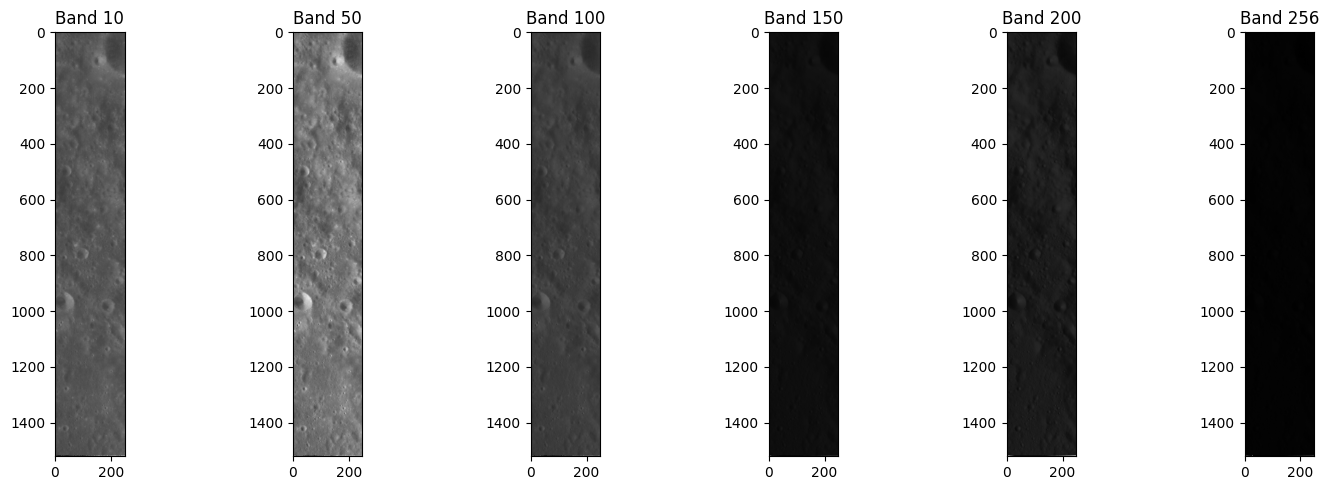

In [18]:
fig, axes = plt.subplots(1, 6, figsize=(15, 5))

axes[0].imshow(hyperspectral_data[:,:,10], cmap='gray')
axes[0].set_title('Band 10')

axes[1].imshow(hyperspectral_data[:,:,50], cmap='gray')
axes[1].set_title('Band 50')

axes[2].imshow(hyperspectral_data[:,:,100], cmap='gray')
axes[2].set_title('Band 100')

axes[3].imshow(hyperspectral_data[:,:,150], cmap='gray')
axes[3].set_title('Band 150')

axes[4].imshow(hyperspectral_data[:,:,200], cmap='gray')
axes[4].set_title('Band 200')

axes[5].imshow(hyperspectral_data[:,:,255], cmap='gray')
axes[5].set_title('Band 256')

save_fig("grayscale image of strip at 6 different bands")

plt.show()

# Plot of moon surface with region of interest along with geographical coordinates at a specific band

In [19]:
coord_df = pd.read_csv(geometry_file)

In [20]:
coord_df.head()

,Longitude,Latitude,Pixel,Scan
0,146.275991,12.350115,0,0
1,146.418392,12.347578,50,0
2,146.560712,12.344941,100,0
3,146.702993,12.342201,150,0
4,146.845278,12.339360,200,0


Enter the band: 50


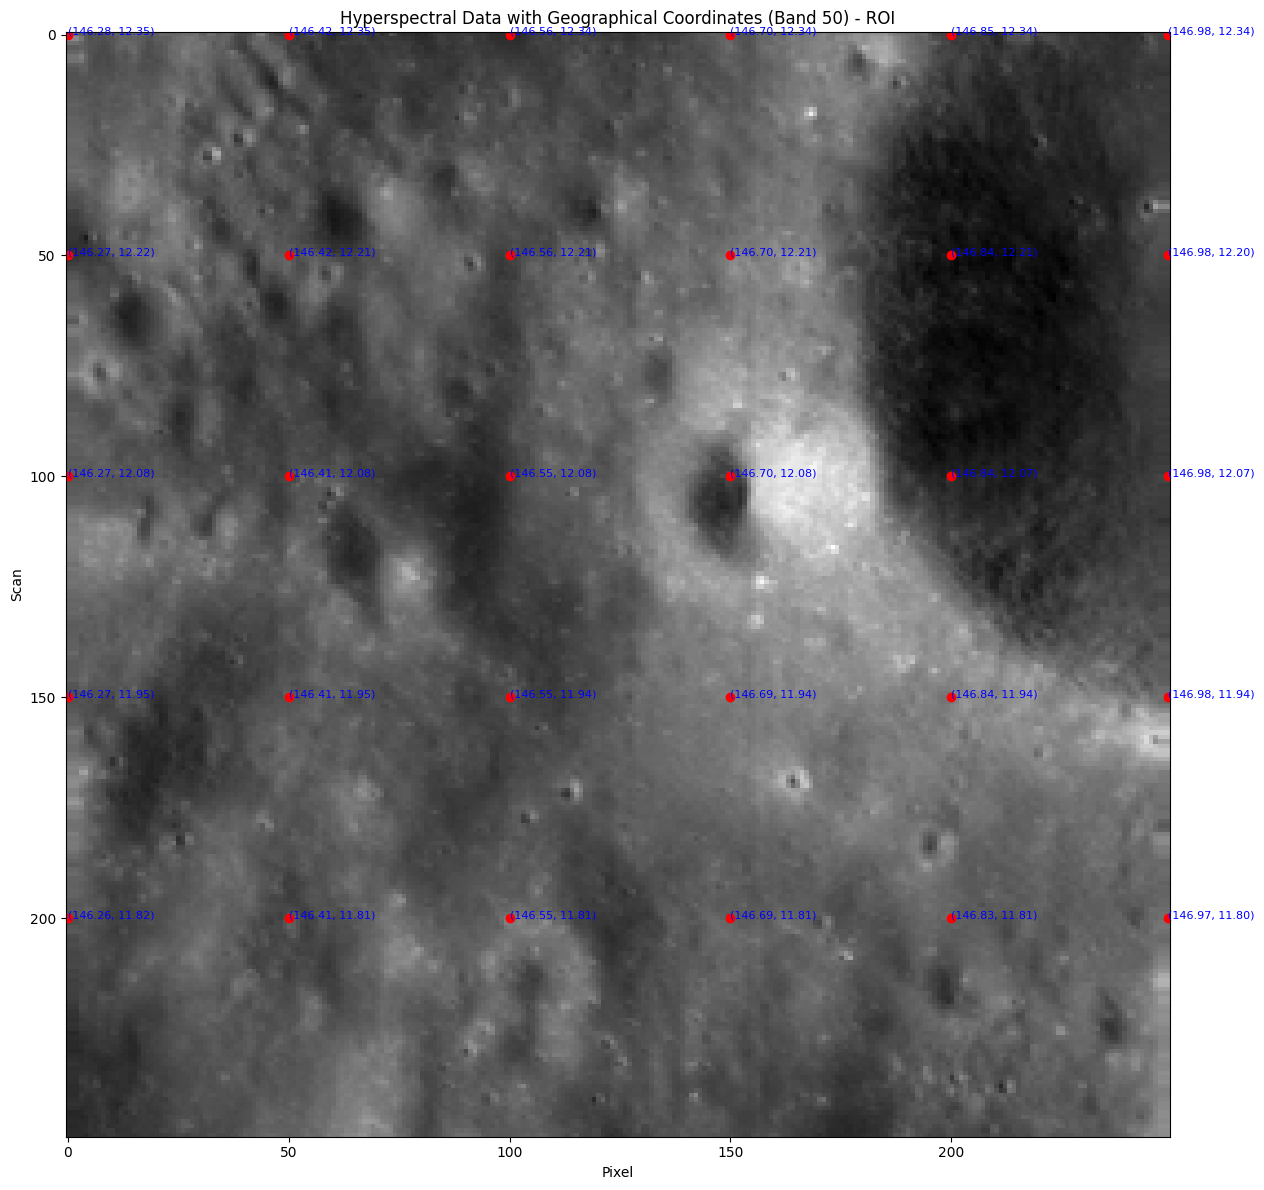

In [21]:
# roi = region of interest
roi_start_x = 0
roi_end_x = 250
roi_start_y = 0
roi_end_y = 250

def plot_roi_hyperspectral_with_coords(band_index):
    plt.figure(figsize=(20, 12))

    plt.imshow(hyperspectral_data[roi_start_y:roi_end_y, roi_start_x:roi_end_x, band_index], cmap='gray')

    for index, row in coord_df.iterrows():
        pixel = row['Pixel']
        scan = row['Scan']


        if roi_start_x <= pixel < roi_end_x and roi_start_y <= scan < roi_end_y:
            lon = row['Longitude']
            lat = row['Latitude']


            plt.plot(pixel - roi_start_x, scan - roi_start_y, 'ro')
            plt.text(pixel - roi_start_x, scan - roi_start_y, f"({lon:.2f}, {lat:.2f})", color='blue', fontsize=8)

    plt.title(f'Hyperspectral Data with Geographical Coordinates (Band {band_index}) - ROI')
    plt.xlabel('Pixel')
    plt.ylabel('Scan')
    save_fig(f"Image geographical coordinates")
    plt.show()

plot_roi_hyperspectral_with_coords(int(input(f"Enter the band: ")))

# Data Preparation
* Reshaping
* Normalization
* PCA

Normalizing the data by dividing each reflectance value by the maximum reflectance value . In order to achieve values between 0-1. This will improve the traning time of the ml models.

In [22]:
normalized_data = hyperspectral_data / np.max(hyperspectral_data)

Reducing the dimention of the data to 2-dimentions

In [23]:
flattened_data = normalized_data.reshape(-1, normalized_data.shape[-1])

In [24]:
flattened_data.shape

(380250, 256)

In [25]:
print(flattened_data[:10])

[[0.00622076 0.00667409 0.00712743 ... 0.00308375 0.00287057 0.00295244]
 [0.00622076 0.00667409 0.00712743 ... 0.00308375 0.00287057 0.00295244]
 [0.00622076 0.00667409 0.00712743 ... 0.00308375 0.00287057 0.00295244]
 ...
 [0.00576955 0.00585054 0.00593153 ... 0.00332213 0.00325173 0.00342796]
 [0.00444085 0.0047199  0.00499894 ... 0.00339197 0.00298064 0.00302577]
 [0.0038356  0.00437755 0.0049195  ... 0.00350411 0.00310666 0.00323648]]


# Dimensionality Reduction using Principal component analysis

* PCA can further reduce the dimensionality by keeping the most important components, making it more manageable for clustering and CNN processing.
* As you can see the 10 principal components capture 98.31% of the variability in your original hyperspectral data

In [26]:
pca = PCA(n_components = 10)
reduces_data = pca.fit_transform(flattened_data)

explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"Explained Variance Ratio by 10 components: {explained_variance}")

Explained Variance Ratio by 10 components: 0.9599848985671997


In [27]:
reduces_data.shape

(380250, 10)

# Clustering

* Applying **k-mean clustering**

Applying k-mean to seperate the data into 5 different clusters . We will use these clusters as labels for classification.

In [28]:
kmean = KMeans(n_clusters=5)

In [29]:
labels = kmean.fit_predict(reduces_data)

In [30]:
def nearest_centroid(X , centroid):
  k = centroid.shape[0]
  c = np.zeros(X.shape[0] , dtype=int)

  for i in range(X.shape[0]):
    distance = []
    for j in range(k):
      norm_ij = np.linalg.norm(X[i] - centroid[j])
      distance.append(norm_ij)
    c[i] = np.argmin(distance)
  return c

def compute_centroid(X , c , k):
  m , n = X.shape
  centroids = np.zeros((k , n))
  for i in range(k):
    centroids[i] = np.mean(X[c == i] , axis = 0)
  return centroids

def initialize_centroid(X , k):
  random_index = np.random.permutation(X.shape[0])
  return X[random_index[:k]]

In [31]:
def run_kMeans(X, initial_centroids, iter, plot_progress=False):
    m, n = X.shape
    k = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids
    idx = np.zeros(m)
    plt.figure(figsize=(8, 6))


    for i in range(iter):
        print("K-Means iteration %d/%d" % (i, iter-1))
        idx = nearest_centroid(X, centroids)
        if plot_progress:
            # plot_progress_kMeans(X, centroids, previous_centroids, idx, k, i)
            previous_centroids = centroids
        centroids = compute_centroid(X, idx, k)
    plt.show()
    return centroids, idx

In [32]:

k = 5
iter = 4
initial_centroids = initialize_centroid(reduces_data , k)
centroids , c = run_kMeans(reduces_data , initial_centroids , iter )

K-Means iteration 0/3
K-Means iteration 1/3
K-Means iteration 2/3
K-Means iteration 3/3


<Figure size 800x600 with 0 Axes>

In [33]:
centroids , c.shape , centroids.shape

(array([[-2.91395164e-03,  1.82249804e-03,  4.24378086e-04,
          1.33586713e-04, -1.26986379e-05,  3.16433943e-05,
         -2.91236993e-05,  1.18878670e-05,  4.41950215e-05,
          1.47618775e-05],
        [ 3.02204699e-03,  1.25783449e-03, -5.85042231e-04,
         -5.71896235e-05,  2.87550993e-05, -1.05999752e-05,
          1.53527617e-05, -1.82585918e-05, -4.53906468e-05,
          3.49238485e-06],
        [-4.92817257e-03,  6.42604753e-03, -4.85050696e-04,
          4.41012962e-04,  1.03395927e-04,  1.21333964e-04,
         -1.67173508e-04,  2.01175004e-04,  2.65809911e-04,
          1.22194004e-04],
        [-8.37991247e-04, -2.27301102e-03,  8.36596708e-04,
         -8.36449690e-05, -7.87582685e-05, -3.46876077e-05,
          5.06837314e-05, -6.79009972e-05, -5.99469313e-05,
         -5.45360926e-05],
        [ 6.16056751e-03, -5.72392857e-03, -1.30208640e-03,
         -3.17504746e-04,  6.99126831e-05, -6.07853399e-05,
          4.63605211e-05,  6.45087312e-06, -7.715824

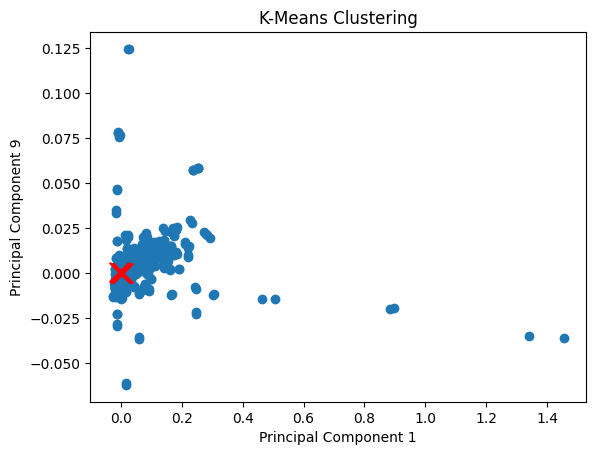

In [34]:
plt.scatter(reduces_data[:, 0], reduces_data[:, 8])
plt.scatter(centroids[:, 0], centroids[:, 8], marker='x', color='red', s=200)
plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 9")
plt.show()

In [35]:
clustered_image = labels.reshape(hyperspectral_data.shape[0] , hyperspectral_data.shape[1])

In [36]:
labels.shape

(380250,)

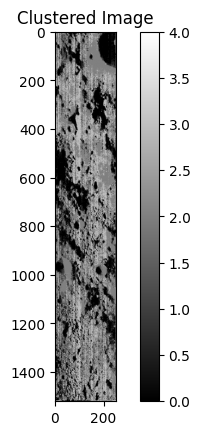

In [37]:
plt.imshow(clustered_image, cmap='gray')
plt.title("Clustered Image")
plt.colorbar()
plt.show()

# Classification
* CNN

Splitting the data into traning and test sets.

In [38]:
X = reduces_data
y = labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
X_train.shape

(304200, 10)

* Defining the input shape of the data to the CNN Model.
* Then building the structure of the CNN model.

In [40]:
X_train_cnn = X_train.reshape(-1, 10, 1, 1)
X_test_cnn = X_test.reshape(-1, 10, 1, 1)

In [41]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(10 ,1,1) ,  padding='same'),
    MaxPooling2D((2, 1)),
    Conv2D(64, (3, 3), activation='relu',  padding='same'),
    MaxPooling2D((2, 1)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 10, 1, 32)           │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 5, 1, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 5, 1, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 2, 1, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 2, 1, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,325 (251.27 KB)

 Trainable params: 64,325 (251.27 KB)

 Non-trainable params: 0 (0.00 B)

Then compiling and fitting the model

In [43]:
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.6381 - loss: 0.7591 - val_accuracy: 0.9751 - val_loss: 0.0718
Epoch 2/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9678 - loss: 0.0796 - val_accuracy: 0.9753 - val_loss: 0.0603
Epoch 3/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 43s 4ms/step - accuracy: 0.9732 - loss: 0.0655 - val_accuracy: 0.9802 - val_loss: 0.0514
Epoch 4/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9769 - loss: 0.0578 - val_accuracy: 0.9819 - val_loss: 0.0469
Epoch 5/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9785 - loss: 0.0521 - val_accuracy: 0.9796 - val_loss: 0.0479
Epoch 6/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9790 - loss: 0.0496 - val_accuracy: 0.9750 - val_loss: 0.0603
Epoch 7/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9800 - loss: 0.0476 - val_accuracy: 0.9803 - val_loss: 0.0467
Epoch 8/10
7605/7605 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9805 - loss: 0

In [44]:
cnn_eval = cnn_model.evaluate(X_test_cnn, y_test)
print(f'CNN Accuracy: {cnn_eval[1]}')

2377/2377 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9860 - loss: 0.0351
CNN Accuracy: 0.9863642454147339


ON TEST SET OUR MODEL IS GIVING ACCURACY OF MORE THAN 98%